# Clasificador KNN para reconocimiento de numeros


# Importacion de librerias


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras

from knn_algoritmo import KNN
from distancia_euclidiana import distancias_euclidianas


## Carga del dataset

El dataset MNIST se carga directamente desde TensorFlow. Este dataset contiene imagenes de digitos escritos a mano, con etiquetas del 0 al 9.


In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


In [3]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
np.unique(y_train)


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

## Visualizacion de algunos datos

Antes de usar KNN, se muestran algunas imagenes del dataset para ver como son los numeros escritos a mano.


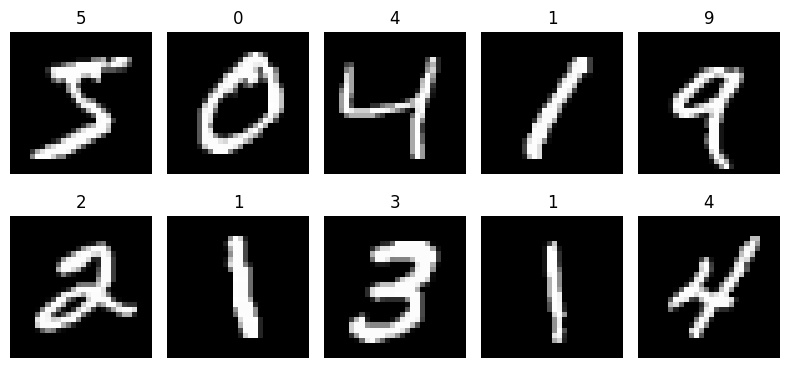

In [5]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


## Cantidad de datos por clase

Se revisa cuantas imagenes hay para cada numero, para verificar que el dataset esta balanceado.


In [6]:
pd.Series(y_train).value_counts().sort_index()


0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

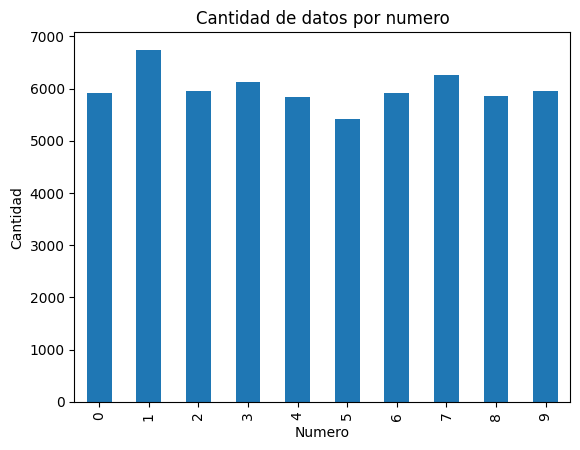

In [7]:
pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
plt.title("Cantidad de datos por numero")
plt.xlabel("Numero")
plt.ylabel("Cantidad")
plt.show()


## Preprocesamiento de datos

Las imagenes tienen pixeles con valores entre 0 y 255. Se normalizan al rango entre 0 y 1 y luego se convierten de matrices 28x28 a vectores de 784 valores para poder calcular distancias entre imagenes.


In [8]:
X_train = (X_train / 255.0).astype(np.float32)
X_test = (X_test / 255.0).astype(np.float32)

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)


In [9]:
print(X_train.min())
print(X_train.max())
print(X_train_flat.shape)
print(X_test_flat.shape)


0.0
1.0
(60000, 784)
(10000, 784)


## Clasificacion con KNN

KNN no entrena pesos como una red neuronal. En `entrenar`, guarda en memoria las observaciones y etiquetas de entrenamiento. Luego, cuando llega una observacion de prueba, calcula la distancia euclidiana contra los datos guardados y decide usando los 3 vecinos mas cercanos.


## Preparacion de datos para KNN

Para esta etapa se tomaron los datos de entrenamiento y prueba del dataset. Las imagenes ya normalizadas se organizaron en vectores de 784 caracteristicas, de modo que puedan ser comparadas por el algoritmo KNN.


In [10]:
cantidad_entrenamiento_knn = X_train_flat.shape[0]
cantidad_prueba_knn = X_test_flat.shape[0]

X_train_knn = X_train_flat
y_train_knn = y_train

X_test_knn = X_test_flat
y_test_knn = y_test

print("Datos de entrenamiento usados:", len(X_train_knn))
print("Datos de prueba usados:", len(X_test_knn))
print("Caracteristicas por imagen:", X_train_knn.shape[1])


Datos de entrenamiento usados: 60000
Datos de prueba usados: 10000
Caracteristicas por imagen: 784


### Entrenamiento del modelo

En esta etapa el modelo solo guarda los datos de entrenamiento. No ajusta pesos como una red neuronal.


In [11]:
import importlib
import knn_algoritmo
import distancia_euclidiana

importlib.reload(distancia_euclidiana)
importlib.reload(knn_algoritmo)

from knn_algoritmo import KNN
from distancia_euclidiana import distancias_euclidianas

knn = KNN(k=3, distancia=distancias_euclidianas, batch_size=100)
knn.entrenar(X_train_knn, y_train_knn)


### Funciones de visualizacion

Se preparan las funciones auxiliares para mostrar predicciones, metricas y graficas de apoyo.


In [12]:
from visualizacion_knn import (
    crear_contexto_visualizacion,
    mostrar_comparacion_metricas,
    mostrar_comparacion_matrices_confusion,
    mostrar_individuo,
    mostrar_pca_lote,
)

contexto_visualizacion = crear_contexto_visualizacion(
    X_train_flat,
    X_test_flat,
    X_test,
    X_test_knn,
    y_test_knn,
    cantidad_entrenamiento_knn,
    y_train_knn=y_train_knn,
)


### Prediccion individual

Se toma una observacion de prueba para mostrar la imagen, su etiqueta real, la prediccion obtenida con KNN y su ubicacion aproximada en PCA. La grafica tambien muestra regiones de decision aproximadas en 2D.


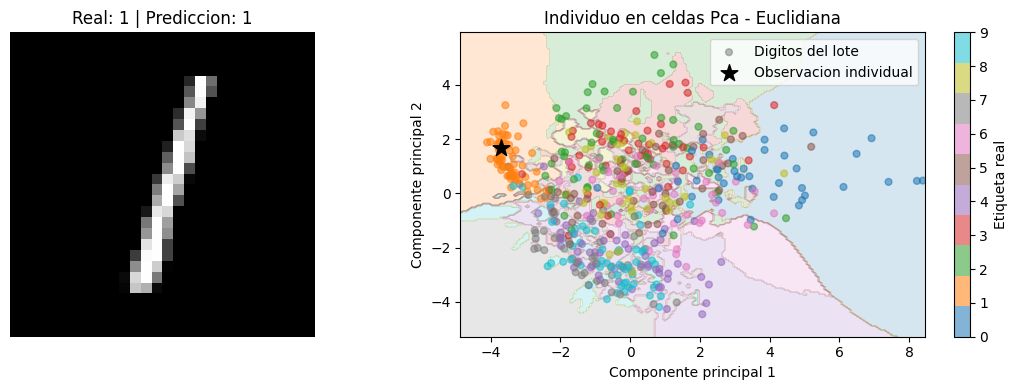

Etiqueta real: 1
Prediccion Euclidiana: 1


1

In [13]:
indice_observacion = 2

mostrar_individuo(
    knn,
    contexto_visualizacion,
    indice=indice_observacion,
    nombre_modelo="Euclidiana",
)


### Prediccion sobre el conjunto de prueba

Se aplica el clasificador KNN con distancia euclidiana al conjunto de prueba y se comparan las etiquetas predichas con las etiquetas reales.


In [14]:
import time

inicio = time.time()
y_pred = knn.predecir_en_lote(X_test_knn, batch_size=100)
tiempo_prediccion = time.time() - inicio

print(f"Tiempo de prediccion: {tiempo_prediccion:.2f} segundos")

predicciones = {
    "Euclidiana": y_pred
}

resultados = pd.DataFrame({
    "real": y_test_knn,
    "pred_euclidiana": y_pred,
})

resultados.head(10)


Tiempo de prediccion: 21.98 segundos


,real,pred_euclidiana
0,7,7
1,2,2
2,1,1
3,0,0
4,4,4
5,1,1
6,4,4
7,9,9
8,5,5
9,9,9


### Metricas de evaluacion

Las metricas muestran el rendimiento del modelo KNN usando distancia euclidiana.


,precision,recall,f1-score,support
0,0.966,0.994,0.980,980.0
1,0.958,0.998,0.978,1135.0
2,0.982,0.965,0.974,1032.0
3,0.963,0.966,0.965,1010.0
4,0.975,0.967,0.971,982.0
5,0.966,0.963,0.965,892.0
6,0.983,0.985,0.984,958.0
7,0.965,0.964,0.964,1028.0
8,0.989,0.938,0.963,974.0
9,0.960,0.959,0.960,1009.0


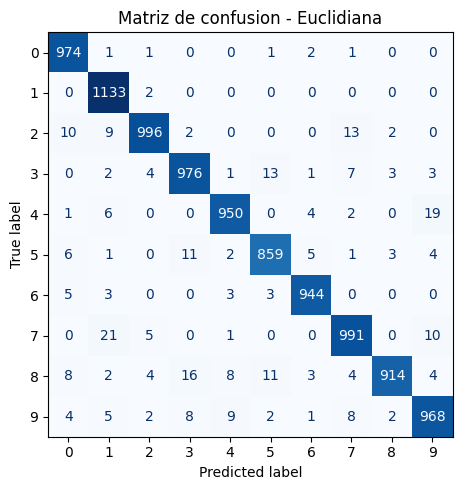

In [15]:
mostrar_comparacion_metricas(y_test_knn, predicciones)
mostrar_comparacion_matrices_confusion(y_test_knn, predicciones)


### Visualizacion de predicciones con Pca

PCA reduce las 784 caracteristicas de cada imagen a 2 componentes principales. La grafica muestra una representacion aproximada de las predicciones y las regiones de decision en ese plano 2D.


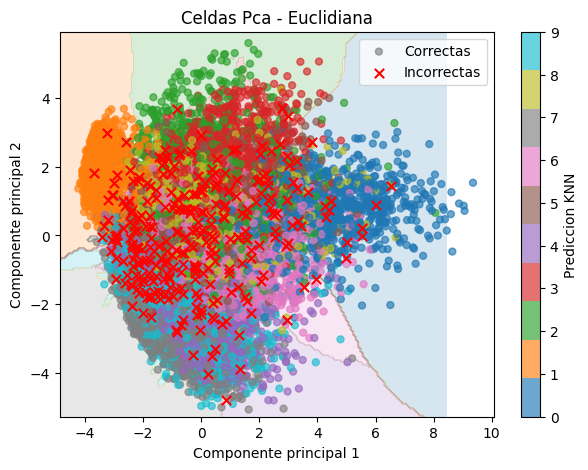

In [16]:
mostrar_pca_lote(
    contexto_visualizacion,
    y_test_knn,
    predicciones,
    k=3,
)
